In [77]:
# ==============================
# Import all the libraries I need  
# ==============================
import pandas as pd                          # For loading and manipulating data
import numpy as np                           # For math operations
import matplotlib.pyplot as plt              # For making charts
import seaborn as sns                        # For nicer charts
from sklearn import model_selection          # For splitting data into train/test
from sklearn import linear_model             # For building the regression model
from sklearn import metrics                  # For evaluating the model
import joblib
import streamlit as st                      # For building the web app

print("All libraries imported successfully!")

All libraries imported successfully!


In [78]:
# ==============================
#Load the dataset
# ==============================
df = pd.read_csv("tips.csv")
# Show the first 5 rows 
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


df.shape  # (rows, columns)

In [81]:
# Statistical summary
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


#Counts of Categories
#To understand if the data is balanced or skewed.

In [83]:
# Count how many Male vs Female customers
df["sex"].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [84]:
# Count smokers vs non-smokers
df["smoker"].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [85]:
# Count by day of the week
df["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [86]:
# Count by meal time (Lunch or Dinner)
df["time"].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

Missing values, duplicates & copying data

In [88]:
# Checking for missing values in each column 
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [89]:
# Checking for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Removing duplicate rows
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Number of duplicate rows: 1
Rows after removing duplicates: 243


In [90]:
# Make a clean copy of the dataset to work with
df2 = df.copy()
print("Working copy created!")

Working copy created!


EDA

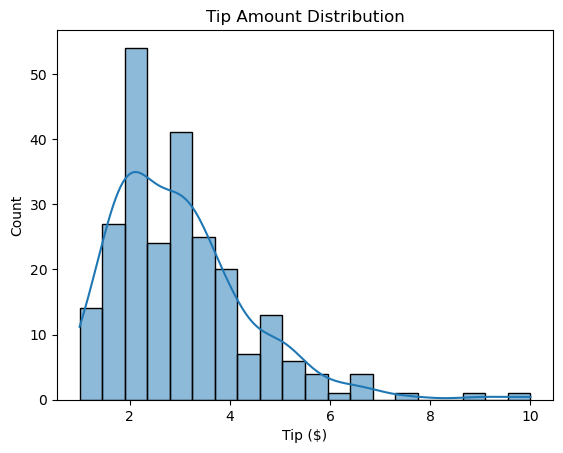

In [92]:
# Distribution of Tips (how often each tip amount appears)
sns.histplot(df2["tip"], bins=20, kde=True)
plt.title("Tip Amount Distribution")
plt.xlabel("Tip ($)")
plt.ylabel("Count")
plt.show()

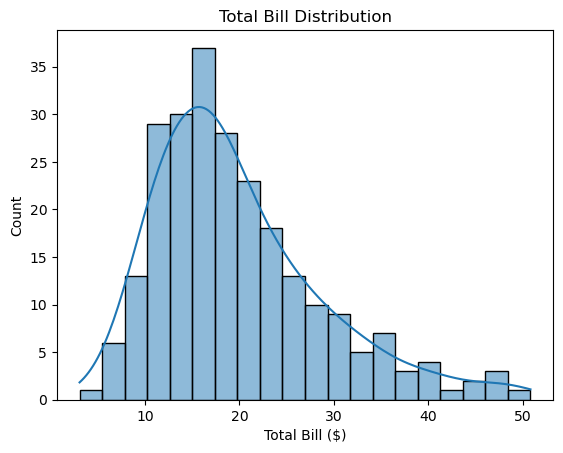

In [93]:
# Distribution of Total Bill
sns.histplot(df2["total_bill"], bins=20, kde=True)
plt.title("Total Bill Distribution")
plt.xlabel("Total Bill ($)")
plt.ylabel("Count")
plt.show()

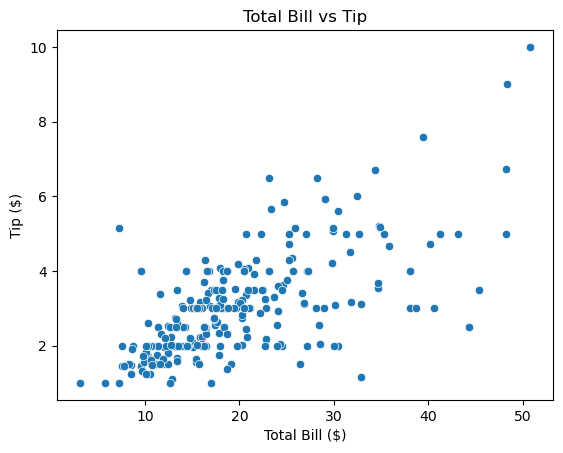

In [94]:
# Scatter plot: Does a higher bill mean a higher tip?
sns.scatterplot(data=df2, x="total_bill", y="tip")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

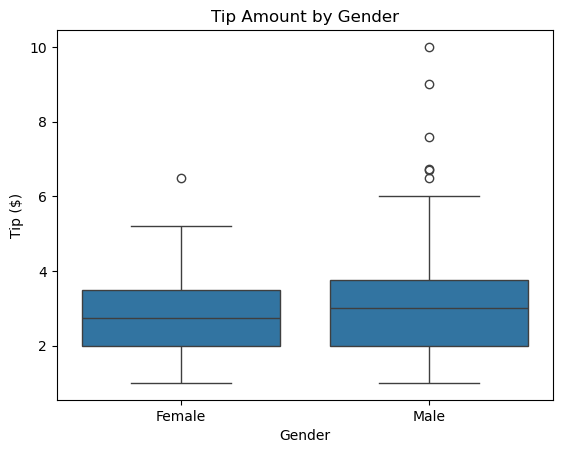

In [95]:
# Box plot: Do men and women tip differently?
sns.boxplot(x=df2["sex"], y=df2["tip"])
plt.title("Tip Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Tip ($)")
plt.show()

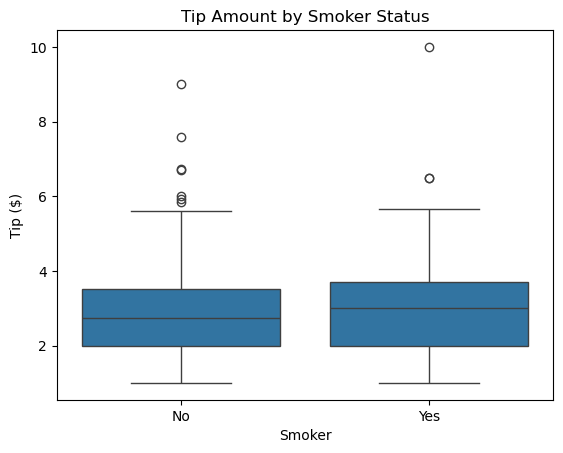

In [96]:
# Box plot: Do smokers tip differently?
sns.boxplot(x=df2["smoker"], y=df2["tip"])
plt.title("Tip Amount by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Tip ($)")
plt.show()

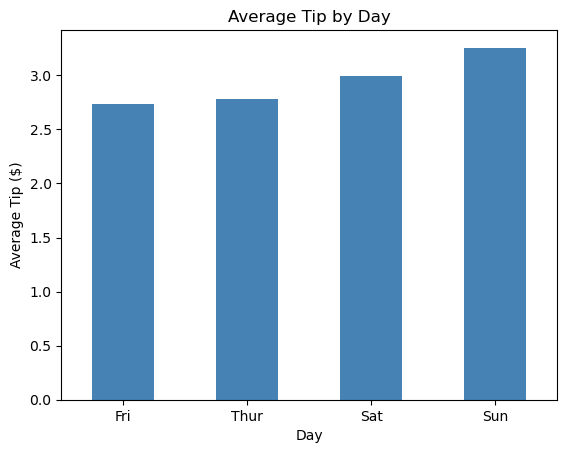

In [97]:
# Bar plot: Which day of the week gets the highest average tips?
df2.groupby("day")["tip"].mean().sort_values().plot(kind="bar", color="steelblue")
plt.title("Average Tip by Day")
plt.xlabel("Day")
plt.ylabel("Average Tip ($)")
plt.xticks(rotation=0)
plt.show()

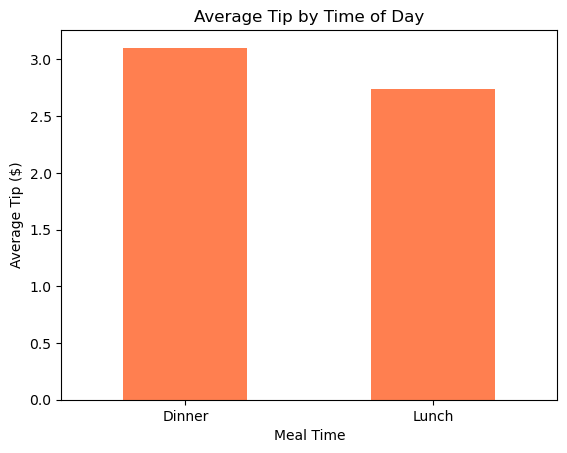

In [98]:
# Bar plot: Lunch vs Dinner tips
df2.groupby("time")["tip"].mean().plot(kind="bar", color="coral")
plt.title("Average Tip by Time of Day")
plt.xlabel("Meal Time")
plt.ylabel("Average Tip ($)")
plt.xticks(rotation=0)
plt.show()

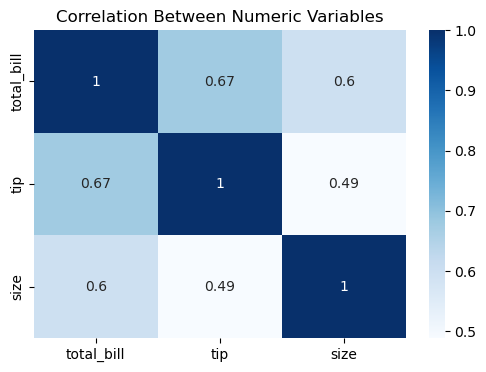

In [99]:
# Correlation heatmap: which numbers are related to each other?
# (Only works on number columns)
plt.figure(figsize=(6, 4))
sns.heatmap(df2[["total_bill", "tip", "size"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation Between Numeric Variables")
plt.show()

# Data Preprocessing

In [101]:
# converting text columns into number columns
df3 = pd.get_dummies(df2)

# The new columns look like
df3.head()

,total_bill,tip,size,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,2,True,False,True,False,False,False,True,False,True,False
1,10.34,1.66,3,False,True,True,False,False,False,True,False,True,False
2,21.01,3.50,3,False,True,True,False,False,False,True,False,True,False
3,23.68,3.31,2,False,True,True,False,False,False,True,False,True,False
4,24.59,3.61,4,True,False,True,False,False,False,True,False,True,False


In [102]:
# all the column names after converting to numerical values
df3.columns.tolist()

['total_bill',
 'tip',
 'size',
 'sex_Female',
 'sex_Male',
 'smoker_No',
 'smoker_Yes',
 'day_Fri',
 'day_Sat',
 'day_Sun',
 'day_Thur',
 'time_Dinner',
 'time_Lunch']

In [103]:
# 'tip' is what I want to predict (y)
y = df3["tip"]

# Everything else is what will be used to predict(X)
# Removing 'tip' from the features
X = df3.drop(columns=["tip"])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (243, 12)
Target (y) shape: (243,)


In [104]:
# Spliting data: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size: ", X_test.shape[0], "rows")

Training set size: 194 rows
Testing set size:  49 rows


In [105]:
# Creating a function for training the models
def run_linreg(cols, X_train, y_train):
    X = X_train[cols]
    linreg = linear_model.LinearRegression()
    linreg.fit(X=X, y=y_train)
    return linreg

In [106]:
# Model 1: Using only total_bill to predict tips
model1_cols = ["total_bill"]
model1 = run_linreg(model1_cols, X_train, y_train)
# model1.fit(X=X_train[model1_cols], y=y_train)
joblib.dump(model1_cols, "./total_bill_model1.pkl")  

print("Model 1 trained! (1 feature: total_bill)")
print("Coefficient (slope):", model1.coef_)

Model 1 trained! (1 feature: total_bill)
Coefficient (slope): [0.09979095]


In [115]:
# Model 2: Using total_bill + size to predict tips
model2_cols = ["total_bill", "size"]
model2 = run_linreg(model2_cols, X_train, y_train)
# model2.fit(X=X_train[model2_cols], y=y_train)
joblib.dump(model2_cols, "./total_bill_size_model2.pkl")
joblib.dump(model2, "total_bill_size_model2.pkl")
print("Model 2 trained! (2 features: total_bill + size)")
print("Coefficients:", model2.coef_)

Model 2 trained! (2 features: total_bill + size)
Coefficients: [0.08433348 0.22819623]


In [108]:
# Model 3: Using ALL features to predict tips
model3_cols = X_train.columns.tolist()  # Use all columns
model3 = linear_model.LinearRegression()
model3.fit(X=X_train[model3_cols], y=y_train)

print("Model 3 trained! (All features)")
print("Number of features used:", len(model3_cols))
print("Coefficients:", model3.coef_)

Model 3 trained! (All features)
Number of features used: 12
Coefficients: [ 0.08548255  0.2109895  -0.00908101  0.00908101  0.0260651  -0.0260651
 -0.05530834  0.04797471  0.11247373 -0.1051401  -0.0973347   0.0973347 ]


#ACTUAL VS PREDICTED 

In [110]:
# for Model 1 
df1 = pd.DataFrame({
        "actual": y_test.values.flatten(),
        "predicted": model1.predict(X=X_test[model1_cols]).flatten()
    })  
df1.head(10)

,actual,predicted
0,3.18,3.013226
1,2.00,1.910536
2,2.74,2.757761
3,1.47,2.110118
4,5.92,3.932301
5,3.11,4.318492
6,3.00,3.844485
7,2.50,2.439428
8,3.23,2.510280
9,2.55,3.425363


In [111]:
# for Model 2
df2 = pd.DataFrame({
        "actual": y_test.values.flatten(),
        "predicted": model2.predict(X=X_test[model2_cols]).flatten()
    })  
df2.head(10)

,actual,predicted
0,3.18,2.880152
1,2.00,1.948267
2,2.74,2.892454
3,1.47,2.116934
4,5.92,3.885059
5,3.11,3.983233
6,3.00,4.267238
7,2.50,2.395234
8,3.23,2.455111
9,2.55,3.228449


In [112]:
# for Model 3
df3 = pd.DataFrame({
        "actual": y_test.values.flatten(),
        "predicted": model3.predict(X=X_test[model3_cols]).flatten()
    })  
df3.head(10)

,actual,predicted
0,3.18,2.889801
1,2.00,2.009718
2,2.74,2.946454
3,1.47,2.116184
4,5.92,3.888084
5,3.11,4.020281
6,3.00,4.182709
7,2.50,2.462775
8,3.23,2.523468
9,2.55,3.307343


In [113]:
# MODEL EVALUATION

    model       MAE       MSE      RMSE
0  model1  0.756551  1.150752  1.072731
1  model2  0.766693  1.165183  1.079437
2  model3  0.766507  1.173003  1.083053


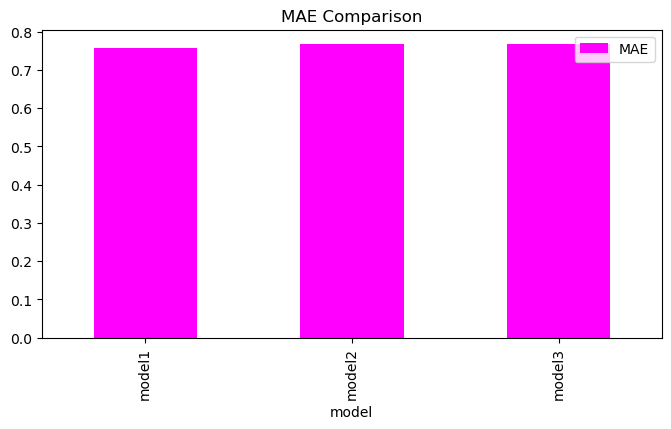

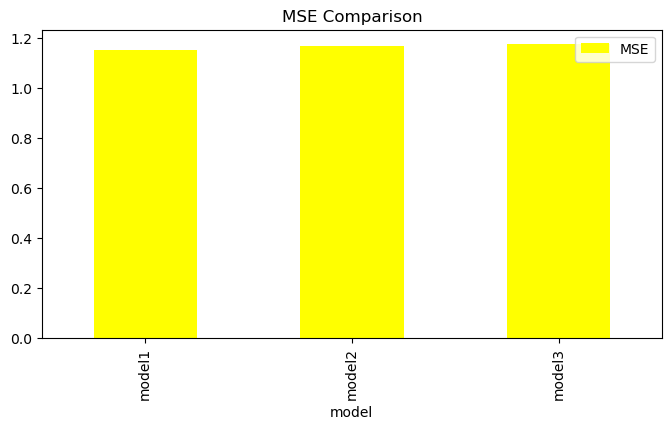

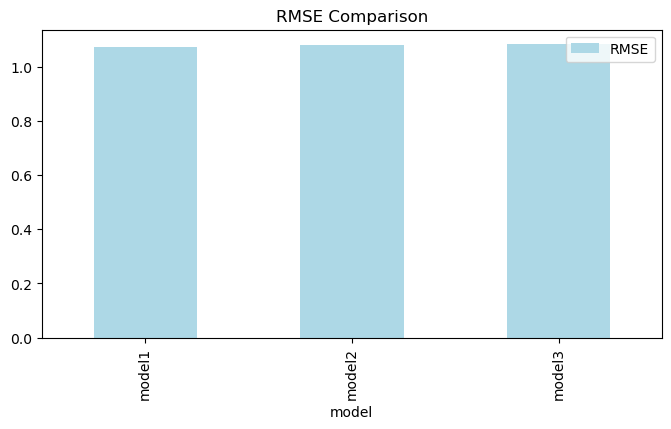

In [114]:
# MAE  = average error in dollars
# MSE  = average squared error
# RMSE = square root of MSE 

mae = []
mse = []
rmse = []

mods = [model1, model2, model3]
X_test_ls = [
    X_test[model1_cols],
    X_test[model2_cols],
    X_test[model3_cols]
]

for mod, Xt in zip(mods, X_test_ls):
    y_pred = mod.predict(Xt)
    mae.append(metrics.mean_absolute_error(y_test, y_pred))
    mse.append(metrics.mean_squared_error(y_test, y_pred))
    rmse.append(np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

evals_df = pd.DataFrame({ "model": ["model1", "model2", "model3"], 
              "MAE": mae, "MSE": mse, "RMSE": rmse})

print(evals_df)

evals_df.plot(kind="bar", x="model", y=["MAE"], figsize=(8, 4), color="fuchsia", title="MAE Comparison")
plt.show()

evals_df.plot(kind="bar", x="model", y=["MSE"], figsize=(8, 4), color ="yellow", title="MSE Comparison")
plt.show()

evals_df.plot(kind="bar", x="model", y=["RMSE"], figsize=(8, 4), color="lightblue", title="RMSE Comparison")
plt.show()